# Feature Engineering

**Autora:** Leydy Osorio Vargas  
**Fecha:** 2026-09-08

## Descripción

Este notebook implementa la limpieza y transformación de los datos de enfermedad cardiaca mediante transformadores y pipelines de Scikit-learn. Parte del archivo estructuralmente corregido en la Tarea 2 y convierte las decisiones del EDA en un proceso reproducible que podrá combinarse con los modelos de las siguientes tareas.

El objetivo es preparar variables predictoras numéricas para modelamiento sin introducir información del conjunto de prueba durante el ajuste de imputadores, encoders o escaladores.


## Alcance y decisiones

- La fuente es `data/02_intermediate/corazon_type_fixed.parquet`.
- Se eliminan duplicados exactos antes de dividir los datos para evitar que una misma observación aparezca en entrenamiento y prueba.
- Las observaciones sin `disease` se conservan separadas, pero no se usan para entrenamiento supervisado ni se imputa el target.
- La división train/test ocurre antes de ajustar cualquier transformación.
- Los valores atípicos se conservan: el EDA mostró valores extremos plausibles y no existen límites clínicos documentados que justifiquen eliminarlos.
- Se utiliza `RobustScaler` para reducir la influencia de valores extremos sin descartarlos.
- La selección automática de atributos se difiere al modelamiento y deberá evaluarse dentro de validación cruzada.
- Las características derivadas son hipótesis estadísticas exploratorias, no reglas clínicas.
- Solo se muestran resúmenes agregados; no se publican registros individuales.


## 📚 Importar librerías y configurar reproducibilidad


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.utils.validation import check_is_fitted

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "disease"

print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")


Pandas: 3.0.5
Scikit-learn: 1.9.0


## 💾 Cargar el dataset intermedio


In [2]:
PROJECT_DIR = Path.cwd().resolve()

if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = next(
        parent
        for parent in PROJECT_DIR.parents
        if (parent / "data").is_dir() and (parent / "pyproject.toml").exists()
    )

INTERMEDIATE_FILE = (
    PROJECT_DIR / "data" / "02_intermediate" / "corazon_type_fixed.parquet"
)

if not INTERMEDIATE_FILE.exists():
    raise FileNotFoundError(
        "No se encontró el Parquet intermedio. Ejecute primero el notebook de la "
        "Tarea 2: notebooks/2-exploration/02.Exploracion-ljov-2026-09-06.ipynb"
    )

heart_df = pd.read_parquet(INTERMEDIATE_FILE)

print(f"Archivo cargado: {INTERMEDIATE_FILE.relative_to(PROJECT_DIR)}")
print(f"Dimensiones: {heart_df.shape[0]:,} filas y {heart_df.shape[1]} columnas")


Archivo cargado: data/02_intermediate/corazon_type_fixed.parquet
Dimensiones: 3,030 filas y 14 columnas


In [3]:
expected_columns = {
    "age",
    "sex",
    "chest_pain",
    "rest_bp",
    "chol",
    "fbs",
    "rest_ecg",
    "max_hr",
    "exang",
    "old_peak",
    "slope",
    "ca",
    "thal",
    TARGET,
}

missing_columns = expected_columns.difference(heart_df.columns)
unexpected_columns = set(heart_df.columns).difference(expected_columns)

if missing_columns or unexpected_columns:
    raise ValueError(
        f"Esquema inesperado. Faltantes: {sorted(missing_columns)}; "
        f"adicionales: {sorted(unexpected_columns)}"
    )

pd.DataFrame(
    {
        "dtype": heart_df.dtypes.astype(str),
        "missing": heart_df.isna().sum(),
        "missing_pct": (heart_df.isna().mean() * 100).round(2),
    }
)


,dtype,missing,missing_pct
age,Int16,32,1.06
sex,category,64,2.11
chest_pain,category,86,2.84
rest_bp,Int16,83,2.74
chol,Int16,87,2.87
fbs,boolean,97,3.20
rest_ecg,category,198,6.53
max_hr,Int16,172,5.68
exang,boolean,153,5.05
old_peak,Float64,152,5.02


## 🧹 Limpieza de datos


### Duplicados y target faltante

La deduplicación se realiza sobre las 14 columnas y antes de la partición. Como no existe un identificador de paciente, esta decisión evita la fuga evidente causada por copias exactas, aunque no permite detectar encuentros repetidos de una misma persona.

El target faltante no se imputa: inventar una etiqueta convertiría observaciones sin diagnóstico conocido en ejemplos supervisados artificiales.


In [4]:
unique_df = heart_df.drop_duplicates().copy()
unlabeled_df = unique_df.loc[unique_df[TARGET].isna()].copy()
modeling_df = unique_df.loc[unique_df[TARGET].notna()].copy()

cleaning_summary = pd.DataFrame(
    {
        "rows": [
            len(heart_df),
            int(heart_df.duplicated().sum()),
            len(unique_df),
            len(unlabeled_df),
            len(modeling_df),
        ]
    },
    index=[
        "original_rows",
        "exact_duplicates_removed",
        "unique_rows",
        "unique_rows_without_target",
        "rows_available_for_modeling",
    ],
)

cleaning_summary


,rows
original_rows,3030
exact_duplicates_removed,2462
unique_rows,568
unique_rows_without_target,88
rows_available_for_modeling,480


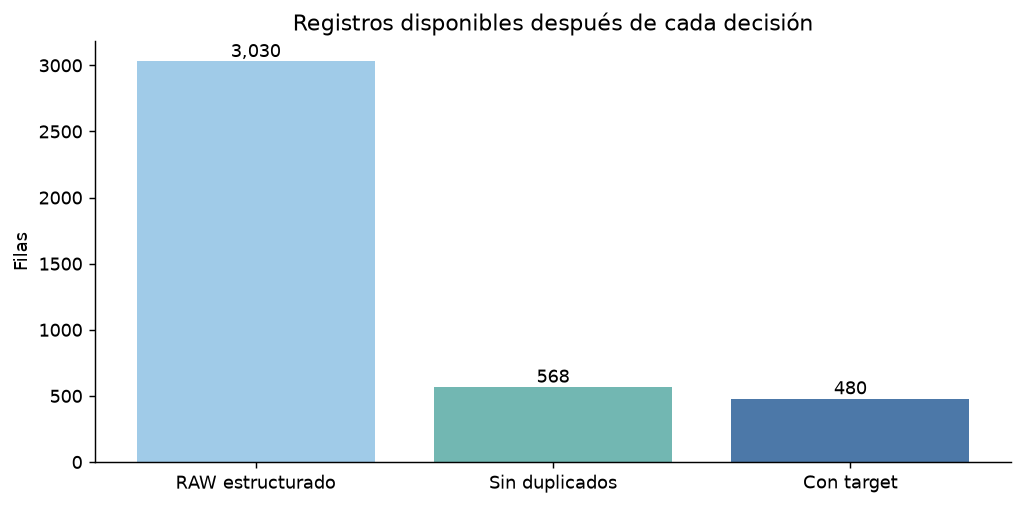

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
stages = ["RAW estructurado", "Sin duplicados", "Con target"]
counts = [len(heart_df), len(unique_df), len(modeling_df)]
bars = ax.bar(stages, counts, color=["#A0CBE8", "#72B7B2", "#4C78A8"])
ax.bar_label(bars, fmt="{:,.0f}")
ax.set(title="Registros disponibles después de cada decisión", ylabel="Filas")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Tratamiento de valores atípicos


In [6]:
original_numeric_features = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
outlier_records = []

for column in original_numeric_features:
    values = modeling_df[column].dropna().astype(float)
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    mask = (values < lower_fence) | (values > upper_fence)
    outlier_records.append(
        {
            "variable": column,
            "lower_fence": lower_fence,
            "upper_fence": upper_fence,
            "outlier_count": int(mask.sum()),
            "decision": "conservar y usar escalado robusto",
        }
    )

outlier_strategy = pd.DataFrame(outlier_records).set_index("variable")
outlier_strategy.round(2)


,lower_fence,upper_fence,outlier_count,decision
variable,,,,
age,28.50,80.50,0,conservar y usar escalado robusto
rest_bp,90.00,170.00,10,conservar y usar escalado robusto
chol,113.12,374.12,6,conservar y usar escalado robusto
max_hr,97.50,205.50,8,conservar y usar escalado robusto
old_peak,-2.70,4.50,4,conservar y usar escalado robusto


Los límites de Tukey identifican extremos estadísticos, no errores clínicos. Por ello no se recortan ni eliminan valores. Esta decisión deberá revisarse si la fuente proporciona unidades, límites fisiológicos validados o evidencia de errores de captura.


## 🎯 Separar predictores y target


In [7]:
X = modeling_df.drop(columns=TARGET)
y = modeling_df[TARGET].astype("int8")

target_summary = pd.DataFrame(
    {
        "count": y.value_counts().sort_index(),
        "percentage": (y.value_counts(normalize=True).sort_index() * 100).round(2),
    }
).rename(index={0: "sin_enfermedad", 1: "con_enfermedad"})

target_summary


,count,percentage
disease,,
sin_enfermedad,250,52.08
con_enfermedad,230,47.92


## ✂️ División train/test antes del preprocesamiento


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "positive_rate_pct": [
            y_train.mean() * 100,
            y_test.mean() * 100,
        ],
    },
    index=["train", "test"],
)

split_summary.round(2)


,rows,positive_rate_pct
train,384,47.92
test,96,47.92


In [9]:
train_hashes = set(pd.util.hash_pandas_object(X_train.astype("string"), index=False))
test_hashes = set(pd.util.hash_pandas_object(X_test.astype("string"), index=False))
shared_rows = train_hashes.intersection(test_hashes)

assert not shared_rows, "Se encontraron predictores idénticos en train y test."
assert X_train.index.intersection(X_test.index).empty
assert abs(y_train.mean() - y_test.mean()) < 0.02

print("Validación de partición:")
print("- No existen índices compartidos entre train y test.")
print("- No existen filas predictoras idénticas entre train y test.")
print("- La estratificación conserva la proporción del target.")


Validación de partición:
- No existen índices compartidos entre train y test.
- No existen filas predictoras idénticas entre train y test.
- La estratificación conserva la proporción del target.


## 👩‍🏭 Ingeniería de atributos


Se incorporan cuatro hipótesis derivadas de los hallazgos del EDA:

1. `age_squared`: permite representar una relación no lineal con la edad.
2. `old_peak_slope_interaction`: resume la interacción observada entre depresión y pendiente del segmento ST.
3. `max_hr_old_peak_interaction`: permite a modelos lineales representar conjuntamente la frecuencia cardiaca máxima y `old_peak`.
4. `chest_pain_exang`: combinación nominal entre tipo de dolor torácico y angina inducida por ejercicio.

Las variables originales se conservan. La utilidad real de las derivadas deberá compararse dentro de validación cruzada en las siguientes tareas.


In [10]:
class HeartFeatureEngineer(BaseEstimator, TransformerMixin):
    '''Normaliza tipos y agrega hipótesis de atributos sin ajustar estadísticas.'''

    derived_features = (
        "age_squared",
        "old_peak_slope_interaction",
        "max_hr_old_peak_interaction",
        "chest_pain_exang",
    )

    numeric_input = (
        "age",
        "rest_bp",
        "chol",
        "max_hr",
        "old_peak",
        "slope",
        "ca",
    )
    binary_input = ("fbs", "exang")
    nominal_input = ("sex", "chest_pain", "rest_ecg", "thal")

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("HeartFeatureEngineer requiere un pandas DataFrame.")
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        check_is_fitted(self, "feature_names_in_")
        transformed = X.copy()

        for column in self.numeric_input:
            transformed[column] = pd.to_numeric(
                transformed[column], errors="coerce"
            ).astype(float)

        for column in self.binary_input:
            mapped = transformed[column].map({False: 0.0, True: 1.0})
            transformed[column] = mapped.to_numpy(dtype=float, na_value=np.nan)

        for column in self.nominal_input:
            values = transformed[column].astype("string")
            transformed[column] = values.astype(object).where(
                values.notna(), np.nan
            )

        transformed["age_squared"] = transformed["age"] ** 2
        transformed["old_peak_slope_interaction"] = (
            transformed["old_peak"] * transformed["slope"]
        )
        transformed["max_hr_old_peak_interaction"] = (
            transformed["max_hr"] * transformed["old_peak"]
        )

        exang_label = transformed["exang"].map({0.0: "no", 1.0: "yes"})
        valid_interaction = transformed["chest_pain"].notna() & exang_label.notna()
        chest_pain_exang = pd.Series(
            np.nan,
            index=transformed.index,
            dtype=object,
        )
        chest_pain_exang.loc[valid_interaction] = (
            transformed.loc[valid_interaction, "chest_pain"].astype(str)
            + "__"
            + exang_label.loc[valid_interaction]
        )
        transformed["chest_pain_exang"] = chest_pain_exang

        return transformed

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "feature_names_in_")
        base_features = (
            self.feature_names_in_
            if input_features is None
            else np.asarray(input_features, dtype=object)
        )
        return np.asarray(
            [*base_features, *self.derived_features],
            dtype=object,
        )


## 🧱 Definir grupos y estrategias de transformación


In [11]:
numeric_features = [
    "age",
    "rest_bp",
    "chol",
    "max_hr",
    "old_peak",
    "ca",
    "age_squared",
    "old_peak_slope_interaction",
    "max_hr_old_peak_interaction",
]
binary_features = ["fbs", "exang"]
ordinal_features = ["slope"]
nominal_features = [
    "sex",
    "chest_pain",
    "rest_ecg",
    "thal",
    "chest_pain_exang",
]

transformation_plan = pd.DataFrame(
    [
        (
            "Numéricas",
            ", ".join(numeric_features),
            "Mediana + indicador de faltante + RobustScaler",
        ),
        (
            "Binarias",
            ", ".join(binary_features),
            "Moda; conservar codificación 0/1",
        ),
        (
            "Ordinal",
            ", ".join(ordinal_features),
            "Moda; conservar orden 1 < 2 < 3",
        ),
        (
            "Nominales",
            ", ".join(nominal_features),
            "Categoría missing + OneHotEncoder",
        ),
    ],
    columns=["group", "features", "strategy"],
).set_index("group")

transformation_plan


,features,strategy
group,,
Numéricas,"age, rest_bp, chol, max_hr, old_peak, ca, age_...",Mediana + indicador de faltante + RobustScaler
Binarias,"fbs, exang",Moda; conservar codificación 0/1
Ordinal,slope,Moda; conservar orden 1 < 2 < 3
Nominales,"sex, chest_pain, rest_ecg, thal, chest_pain_exang",Categoría missing + OneHotEncoder


`fbs` mostró una asociación univariable débil, pero no se elimina: seleccionar variables usando todo el dataset antes de validar modelos podría introducir sesgo. La comparación con y sin este atributo deberá realizarse dentro de validación cruzada.


## 🔧 Crear el pipeline de Scikit-learn


In [12]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True,
            ),
        ),
        ("scaler", RobustScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent", keep_empty_features=True),
        )
    ]
)

ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent", keep_empty_features=True),
        )
    ]
)

nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="missing",
                keep_empty_features=True,
            ),
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("binary", binary_pipeline, binary_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("nominal", nominal_pipeline, nominal_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

feature_pipeline = Pipeline(
    steps=[
        ("feature_engineering", HeartFeatureEngineer()),
        ("preprocessor", preprocessor),
    ]
)

print(feature_pipeline)


Pipeline(steps=[('feature_engineering', HeartFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 keep_empty_features=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'rest_bp', 'chol',
                                                   'max_hr', 'old_peak', 'ca',
                                                   'age_squared',
                                                   'old_peak_slope_i

## 🏋️ Ajustar solo con train y transformar ambos conjuntos


In [13]:
feature_pipeline.fit(X_train, y_train)

transformed_feature_names = feature_pipeline.get_feature_names_out()
X_train_transformed = pd.DataFrame(
    feature_pipeline.transform(X_train),
    columns=transformed_feature_names,
    index=X_train.index,
)
X_test_transformed = pd.DataFrame(
    feature_pipeline.transform(X_test),
    columns=transformed_feature_names,
    index=X_test.index,
)

transformed_shapes = pd.DataFrame(
    {
        "rows": [len(X_train_transformed), len(X_test_transformed)],
        "features": [
            X_train_transformed.shape[1],
            X_test_transformed.shape[1],
        ],
        "missing_cells": [
            int(X_train_transformed.isna().sum().sum()),
            int(X_test_transformed.isna().sum().sum()),
        ],
    },
    index=["train_transformed", "test_transformed"],
)

transformed_shapes


,rows,features,missing_cells
train_transformed,384,46,0
test_transformed,96,46,0


In [14]:
feature_name_summary = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "pipeline_group": [name.split("__", maxsplit=1)[0] for name in transformed_feature_names],
    }
)

feature_group_summary = (
    feature_name_summary.groupby("pipeline_group")
    .size()
    .rename("number_of_output_features")
    .to_frame()
)

feature_group_summary


,number_of_output_features
pipeline_group,
binary,2
nominal,25
numeric,18
ordinal,1


In [15]:
feature_name_summary


,transformed_feature,pipeline_group
0,numeric__age,numeric
1,numeric__rest_bp,numeric
2,numeric__chol,numeric
3,numeric__max_hr,numeric
4,numeric__old_peak,numeric
5,numeric__ca,numeric
6,numeric__age_squared,numeric
7,numeric__old_peak_slope_interaction,numeric
8,numeric__max_hr_old_peak_interaction,numeric
9,numeric__missingindicator_age,numeric


## ✅ Validar el resultado del pipeline


In [16]:
validations = {
    "same_number_of_output_features": (
        X_train_transformed.shape[1] == X_test_transformed.shape[1]
    ),
    "train_has_no_missing_values": not X_train_transformed.isna().any().any(),
    "test_has_no_missing_values": not X_test_transformed.isna().any().any(),
    "train_is_numeric": all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in X_train_transformed.dtypes
    ),
    "test_is_numeric": all(
        pd.api.types.is_numeric_dtype(dtype)
        for dtype in X_test_transformed.dtypes
    ),
    "target_is_binary": set(y_train.unique()).union(y_test.unique()) == {0, 1},
    "target_not_in_features": not any(
        TARGET in name for name in transformed_feature_names
    ),
    "no_train_test_index_overlap": X_train.index.intersection(X_test.index).empty,
}

validation_summary = pd.Series(validations, name="passed").to_frame()
assert validation_summary["passed"].all(), validation_summary

validation_summary


,passed
same_number_of_output_features,True
train_has_no_missing_values,True
test_has_no_missing_values,True
train_is_numeric,True
test_is_numeric,True
target_is_binary,True
target_not_in_features,True
no_train_test_index_overlap,True


In [17]:
fitted_numeric_imputer = (
    feature_pipeline.named_steps["preprocessor"]
    .named_transformers_["numeric"]
    .named_steps["imputer"]
)
full_engineered_reference = feature_pipeline.named_steps[
    "feature_engineering"
].transform(X)

fitted_statistics = pd.DataFrame(
    {
        "feature": numeric_features,
        "train_median_used_for_imputation": fitted_numeric_imputer.statistics_,
        "full_modeling_median_for_reference": [
            pd.to_numeric(
                full_engineered_reference[column], errors="coerce"
            ).median()
            for column in numeric_features
        ],
    }
).set_index("feature")

fitted_statistics.round(2)


,train_median_used_for_imputation,full_modeling_median_for_reference
feature,,
age,56.0,56.0
rest_bp,130.0,130.0
chol,245.0,242.5
max_hr,152.0,152.0
old_peak,0.6,0.8
ca,0.0,0.0
age_squared,3136.0,3136.0
old_peak_slope_interaction,0.8,1.0
max_hr_old_peak_interaction,103.8,113.4


Las estadísticas aprendidas por los imputadores provienen de `X_train`. La comparación con la mediana completa se muestra únicamente como auditoría posterior; esos valores completos no participaron en el ajuste del pipeline.


### Verificar categorías desconocidas


In [18]:
unknown_category_example = X_test.iloc[[0]].copy()
unknown_category_example["sex"] = "Unknown"
unknown_transformed = feature_pipeline.transform(unknown_category_example)

assert unknown_transformed.shape[1] == X_test_transformed.shape[1]
assert not np.isnan(unknown_transformed.astype(float)).any()

print(
    "El pipeline acepta una categoría nominal no observada en train, "
    "mantiene el número de atributos y no genera valores faltantes."
)


El pipeline acepta una categoría nominal no observada en train, mantiene el número de atributos y no genera valores faltantes.


## 📦 Uso recomendado en las siguientes tareas


In [19]:
reusable_artifacts = pd.DataFrame(
    {
        "object": [
            "feature_pipeline",
            "X_train / X_test",
            "y_train / y_test",
            "unlabeled_df",
        ],
        "purpose": [
            "Transformador que debe combinarse con cada modelo.",
            "Predictores separados antes de ajustar transformaciones.",
            "Target binario estratificado.",
            "Observaciones reservadas hasta recuperar una etiqueta confiable.",
        ],
    }
).set_index("object")

reusable_artifacts


,purpose
object,
feature_pipeline,Transformador que debe combinarse con cada mod...
X_train / X_test,Predictores separados antes de ajustar transfo...
y_train / y_test,Target binario estratificado.
unlabeled_df,Observaciones reservadas hasta recuperar una e...


Para validación cruzada no debe utilizarse `X_train_transformed` directamente. La práctica correcta es construir `Pipeline([("features", feature_pipeline), ("model", estimator)])` y entregar ese pipeline completo a la validación cruzada. Así, cada fold ajustará sus propios imputadores, encoders y escaladores exclusivamente con su subconjunto de entrenamiento.

Tampoco se persiste en este notebook un dataset transformado como fuente canónica: eso reduciría la reproducibilidad y facilitaría usar accidentalmente transformaciones ajustadas fuera del fold correspondiente.


## 💡 Recomendaciones e ideas


1. Comparar el pipeline completo con una versión sin atributos derivados para medir su aporte real mediante validación cruzada.
2. Evaluar mediana frente a `KNNImputer` exclusivamente dentro de los folds de entrenamiento.
3. Comparar `RobustScaler` con `StandardScaler` para modelos lineales y basados en distancia; los modelos de árboles pueden usar un pipeline alternativo sin escalado.
4. Evaluar `slope` y `ca` como ordinales frente a One-Hot Encoding.
5. Investigar el origen de los 2.462 duplicados y obtener un identificador anónimo de paciente o encuentro.
6. Recuperar las 88 etiquetas faltantes si la fuente lo permite; no generar etiquetas sintéticas.
7. Priorizar recall/sensibilidad en las tareas de modelamiento, sin dejar de reportar precisión, especificidad, F1 y matriz de confusión.


## 📌 Conclusiones


- La limpieza reduce 3.030 filas a 568 observaciones únicas; 480 tienen un target válido y pueden participar en modelamiento supervisado.
- La deduplicación antes de la partición evita la fuga directa causada por registros idénticos.
- La división estratificada conserva una proporción similar de `disease` en train y test.
- El pipeline ajusta imputación, codificación y escalado exclusivamente con train.
- Las variables numéricas se imputan con la mediana y se escalan de forma robusta; las nominales conservan una categoría explícita para faltantes y aceptan categorías nuevas.
- Los predictores transformados son completamente numéricos, no contienen valores faltantes y tienen el mismo esquema en train y test.
- Los valores atípicos se conservan porque no existe evidencia suficiente para clasificarlos como errores.
- El pipeline queda preparado para combinarse con un `DummyClassifier` o con la heurística en la tarea del modelo baseline.

**Nota ética:** este procesamiento es educativo y exploratorio. No constituye validación clínica ni habilita el uso del modelo para decisiones asistenciales reales.


## 📖 Referencias


- [Evaluación del curso: Ciencia de Datos en Producción](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/intro/evaluacion/).
- [Ejemplo del profesor: Feature Engineering del proyecto Titanic](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/4-feat_eng/).
- [Scikit-learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html).
- [Scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html).
- Notebook de análisis previo: `notebooks/3-analysis/03.Analisis-ljov-2026-09-08.ipynb`.
